In [ ]:
!pip install gdown
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install monthly_returns_heatmap
!pip install datetime
!pip install requests

  Preparing metadata (setup.py) ... done
  Created wheel for monthly_returns_heatmap: filename=monthly_returns_heatmap-0.0.11-py3-none-any.whl size=8112 sha256=4c08812dd7eba360fbf28a8f4292ee331e2ed90a7038fa1f1a92258d851800e9
  Stored in directory: /root/.cache/pip/wheels/a8/68/93/e7887114a1f27ed095dbb50aed4d59bd66341e43a990725711
Successfully built monthly_returns_heatmap
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
from datetime import datetime, timedelta, time
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import monthly_returns_heatmap as mrh
import gdown



def calculate_shares(account_size, risk_percent, risk_amount, price, max_leverage):
    return int(min((account_size * risk_percent) / risk_amount, (max_leverage * account_size) / price))

def backtest_orb_strategy(df, initial_capital=25000, risk_percent=0.01, max_leverage=4, commission=0.0005, slippage=0.0,
                          tp=10, signal_price='Close', position_bar='next', exec_price='Close', start_t='09:30', end_t='16:00', second_bar_t='09:35'):

    data = df.copy()

    start_time = pd.to_datetime(start_t).time()
    end_time = pd.to_datetime(end_t).time()
    second_bar_time = pd.to_datetime(second_bar_t).time()

    #Only keeping market hour data

    data = data[(data.index.time >= start_time) & (data.index.time <= end_time)]
    account_value = initial_capital
    positions = []
    equity_curve = [initial_capital]
    dates = [data.index[0]]

    # Calculate buy and hold equity curve
    qqq_shares = initial_capital // data.iloc[0]['Open']
    buy_hold_equity = [initial_capital]

    for date, group in data.groupby(data.index.date):
        if len(group) < 2:
            continue

        first_candle = group.iloc[0]
        second_candle = group.iloc[1]

        if first_candle.name.time() != start_time or second_candle.name.time() != second_bar_time:
            #print(f'Second bar time: {second_bar_time}')
            #print(f'First candle time: {first_candle.name}')
            #print(f'Second candle time: {second_candle.name}')
            #print('Skipping to the next trading day.')
            continue #Skipping if time on first bar is not 9:30 am or second bar is not 9:35 am

        if first_candle['Close'] > first_candle['Open']:  # Bullish
            entry_price = second_candle['Open'] * (1 + slippage)
            stop_loss = first_candle['Low']
            direction = 1
        elif first_candle['Close'] < first_candle['Open']:  # Bearish
            entry_price = second_candle['Open'] * (1 - slippage)
            stop_loss = first_candle['High']
            direction = -1
        else:  # Doji
            continue

        risk_amount = abs(entry_price - stop_loss)
        shares = calculate_shares(account_value, risk_percent, risk_amount, entry_price, max_leverage)

        target_price = entry_price + (tp * risk_amount * direction)

        position = {
            'Entry Date': second_candle.name,
            'Entry Price': entry_price,
            'Shares': shares,
            'Direction': direction,
            'Stop Loss': stop_loss,
            'Target': target_price,
            'Exit Date': None,
            'Exit Price': None,
            'Profit/Loss': 0
        }

        for i in range(2, len(group)):
            current_candle = group.iloc[i]
            if i + 1 < len(group):
                next_candle = group.iloc[i + 1]
            else:
                next_candle = None

            if position_bar == 'current':
                exec_bar = current_candle
            elif position_bar == 'next':
                exec_bar = next_candle


            if direction == 1:
                if current_candle[signal_price] <= stop_loss:
                    position['Exit Date'] = exec_bar.name if exec_bar is not None else current_candle.name
                    position['Exit Price'] = exec_bar[exec_price] if exec_bar is not None else current_candle[exec_price]
                    position['Exit Price'] *= (1 - slippage)
                    break
                elif current_candle[signal_price] >= target_price:
                    position['Exit Date'] = exec_bar.name if exec_bar is not None else current_candle.name
                    position['Exit Price'] = exec_bar[exec_price] if exec_bar is not None else current_candle[exec_price]
                    position['Exit Price'] *= (1 - slippage)
                    break
            else:
                if current_candle[signal_price] >= stop_loss:
                    position['Exit Date'] = exec_bar.name if exec_bar is not None else current_candle.name
                    position['Exit Price'] = exec_bar[exec_price] if exec_bar is not None else current_candle[exec_price]
                    position['Exit Price'] *= (1 + slippage)
                    break
                elif current_candle[signal_price] <= target_price:
                    position['Exit Date'] = exec_bar.name if exec_bar is not None else current_candle.name
                    position['Exit Price'] = exec_bar[exec_price] if exec_bar is not None else current_candle[exec_price]
                    position['Exit Price'] *= (1 + slippage)
                    break

        if position['Exit Date'] is None:
            position['Exit Date'] = group.iloc[-1].name
            position['Exit Price'] = group.iloc[-1]['Close']

        position['Profit/Loss'] = (position['Exit Price'] - position['Entry Price']) * position['Shares'] * direction
        position['Profit/Loss'] -= 2 * commission * position['Shares']  # Commission for both entry and exit

        position['Hold Time'] = (position['Exit Date'] - position['Entry Date']).total_seconds() / 3600 #in hours
        position['Return'] = position['Profit/Loss'] / (position['Entry Price'] * position['Shares'])

        account_value += position['Profit/Loss']
        positions.append(position)

        equity_curve.append(account_value)
        dates.append(date)

        # Update buy and hold equity
        buy_hold_equity.append(qqq_shares * group.iloc[-1]['Close'])

    return pd.DataFrame(positions), account_value, equity_curve, dates, buy_hold_equity

def calculate_metrics(returns, buy_hold=False):
    total_return = (returns.iloc[-1] / returns.iloc[0] - 1) * 100
    annual_return = (1 + total_return / 100) ** (252 / len(returns)) - 1
    sharpe_ratio = np.sqrt(252) * returns.pct_change().mean() / returns.pct_change().std()
    max_drawdown = (returns / returns.cummax() - 1).min() * 100
    win_rate = (positions['Profit/Loss'] > 0).mean() * 100
    profit_factor = positions[positions['Profit/Loss'] > 0]['Profit/Loss'].sum() / abs(positions[positions['Profit/Loss'] < 0]['Profit/Loss'].sum())
    if buy_hold:
        nb_trades = 1
    else:
        nb_trades = len(positions)

    return pd.DataFrame({
        'Total Return (%)': [total_return],
        'Annual Return (%)': [annual_return * 100],
        'Sharpe Ratio': [sharpe_ratio],
        'Max Drawdown (%)': [max_drawdown],
        'Number of Trades': [nb_trades]
    })


def bt_metrics_plots(symbol, interval, equity_curve, buy_hold_equity, dates):
    # 1. METRICS

    buy_hold_series = pd.Series(buy_hold_equity, index=dates)
    equity_series = pd.Series(equity_curve, index=dates)
    orb_metrics = calculate_metrics(equity_series)
    bh_metrics = calculate_metrics(buy_hold_series, buy_hold=True)

    metrics = pd.concat([orb_metrics, bh_metrics], axis=0).T
    metrics.columns = ["ORB Strategy", "Buy & Hold"]

    display(metrics)

    # 2. EQUITY CURVES
    plt.figure(figsize=(12, 6))
    plt.plot(dates, equity_curve, label='ORB Strategy')
    plt.plot(dates, buy_hold_equity, label='Buy & Hold')
    plt.title(f'{symbol} {interval} ORB Strategy vs. Buy & Hold')
    plt.xlabel('Date')
    plt.ylabel('Account Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. DRAWDOWNS
    rolling_max = equity_series.cummax()
    drawdown = (equity_series - rolling_max) / rolling_max * 100

    plt.figure(figsize=(12, 6))
    plt.plot(dates, drawdown)
    plt.title('Drawdown')
    plt.xlabel('Date')
    plt.ylabel('Drawdown (%)')
    plt.grid(True)
    plt.show()

    # 4. PNL DISTRIBUTION

    plt.figure(figsize=(12, 6))
    plt.hist(positions["Profit/Loss"])
    plt.title('Daily PnL Distribution ($)')
    plt.show()

    # 5. MONTHLY RETURNS HEATMAP

    returns = equity_series.pct_change()

    returns = pd.DataFrame(returns, columns=['daily_return']).dropna()

    returns.index = pd.to_datetime(returns.index)

    #mrh.plot(returns, figsize=(12, 6))

    # 6. TRADE DURATIONS

    plt.figure(figsize=(12, 6))
    plt.hist(positions['Hold Time'], density=True)
    plt.title('Trade Duration Distribution')
    plt.xlabel('Hold Time (hours)')
    plt.show()

    # 7. TRADE RETURNS
    plt.figure(figsize=(12, 6))
    plt.hist(positions['Return'])
    plt.title('Trade Returns Distribution')
    plt.xlabel('Return')
    plt.show()

    #8. ROLLING SHARPE

    window=252

    rolling_sharpe = np.sqrt(window) * equity_series.pct_change().rolling(window=window).mean() / equity_series.pct_change().rolling(window=window).std()
    plt.figure(figsize=(12, 6))
    plt.plot(dates[window:], rolling_sharpe[window:])
    plt.title(f'Rolling Sharpe Ratio ({window}-day window)')
    plt.xlabel('Date')
    plt.ylabel('Sharpe Ratio')
    plt.show()

def import_data(file_id, file_name):
  # Download the file
  url = f'https://drive.google.com/uc?id={file_id}'
  gdown.download(url, file_name, quiet=False)
  df = pd.read_csv(file_name)
  df.set_index('date', inplace=True)
  df.index = pd.to_datetime(df.index)
  return df


In [ ]:
#Import intraday data - I downloaded it from the AlphaVantage API and stored in as csv files
qqq = import_data('1sTEwXyWVGPJ8lA0ZC-QgYF7f1GEmspeN', file_name='QQQ-5min-2016-2024.csv')
tsla = import_data('1KKXw520Ttj3jsLmAHEStRwDHsEc8jUHq', file_name='TSLA-5min-2016-2024.csv')
spy = import_data('189nHYbQ00D-idXP6YyNClHkknexNvTSO', file_name='SPY-5min-2016-2024.csv')

Downloading...
From: https://drive.google.com/uc?id=1sTEwXyWVGPJ8lA0ZC-QgYF7f1GEmspeN
To: /content/QQQ-5min-2016-2024.csv
100%|██████████| 21.3M/21.3M [00:00<00:00, 219MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KKXw520Ttj3jsLmAHEStRwDHsEc8jUHq
To: /content/TSLA-5min-2016-2024.csv
100%|██████████| 18.4M/18.4M [00:00<00:00, 135MB/s]
Downloading...
From: https://drive.google.com/uc?id=189nHYbQ00D-idXP6YyNClHkknexNvTSO
To: /content/SPY-5min-2016-2024.csv
100%|██████████| 22.5M/22.5M [00:00<00:00, 43.6MB/s]


# 1. 5-min ORB on QQQ (parameters as in original paper)

In [ ]:
# PARAMETERS

symbol = 'QQQ'
start_year, end_year = 2016, 2024
interval = '5min'
initial_capital = 25_000
risk_percent = 0.01
max_leverage = 4
commission = 0.0005 #dollar per share
slippage = 0.0 #price percentage
tp_factor = 10
signal_price = 'Close' #TP/SL signals are based on close price
position_bar = 'next'
exec_price = 'Open' #Once a signal is observed, position is taken on Open of next bar
start_t = '09:30'
second_bar_t = '09:35'
end_t = '16:00'


In [ ]:
def import_data(file_id, file_name):
  # Download the file
  url = f'https://drive.google.com/uc?id={file_id}'
  gdown.download(url, file_name, quiet=False)
  df = pd.read_csv(file_name)
  df.set_index('date', inplace=True)
  df.index = pd.to_datetime(df.index)
  return df

qqq = import_data('1sTEwXyWVGPJ8lA0ZC-QgYF7f1GEmspeN', file_name='QQQ-5min-2016-2024.csv')
tsla = import_data('1KKXw520Ttj3jsLmAHEStRwDHsEc8jUHq', file_name='TSLA-5min-2016-2024.csv')

In [ ]:
qqq = import_data('1sTEwXyWVGPJ8lA0ZC-QgYF7f1GEmspeN', file_name='QQQ-5min-2016-2024.csv')
tsla = import_data('1KKXw520Ttj3jsLmAHEStRwDHsEc8jUHq', file_name='TSLA-5min-2016-2024.csv')


Downloading...
From: https://drive.google.com/uc?id=1sTEwXyWVGPJ8lA0ZC-QgYF7f1GEmspeN
To: /content/QQQ-5min-2016-2024.csv
100%|██████████| 21.3M/21.3M [00:00<00:00, 135MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1KKXw520Ttj3jsLmAHEStRwDHsEc8jUHq
To: /content/TSLA-5min-2016-2024.csv
100%|██████████| 18.4M/18.4M [00:00<00:00, 40.1MB/s]


Backtesting Results for 5min ORB strategy on QQQ between 2016 and 2024:


,ORB Strategy,Buy & Hold
Total Return (%),295.782980,299.851640
Annual Return (%),18.854885,19.007614
Sharpe Ratio,0.678986,0.907655
Max Drawdown (%),-34.014947,-35.146221
Number of Trades,2006.000000,1.000000


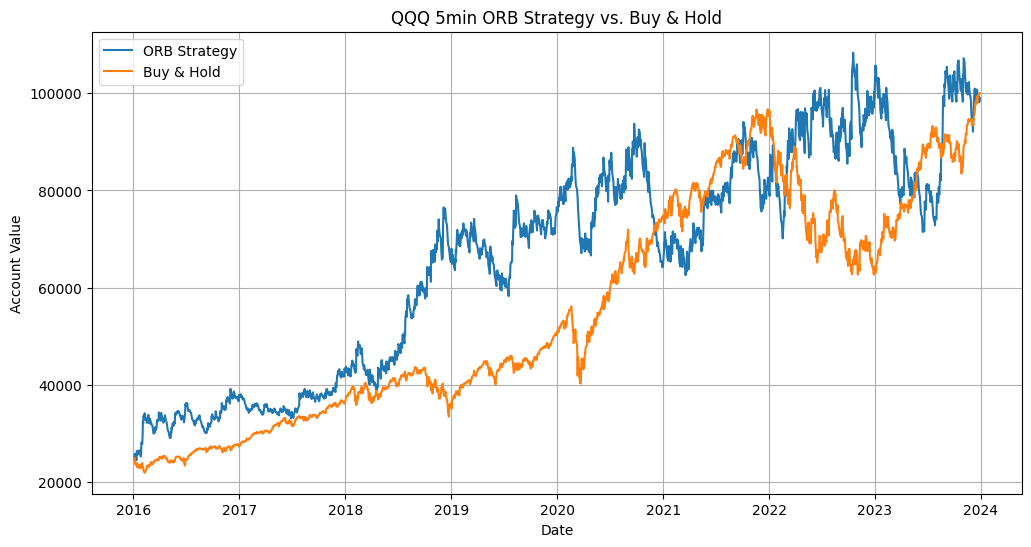

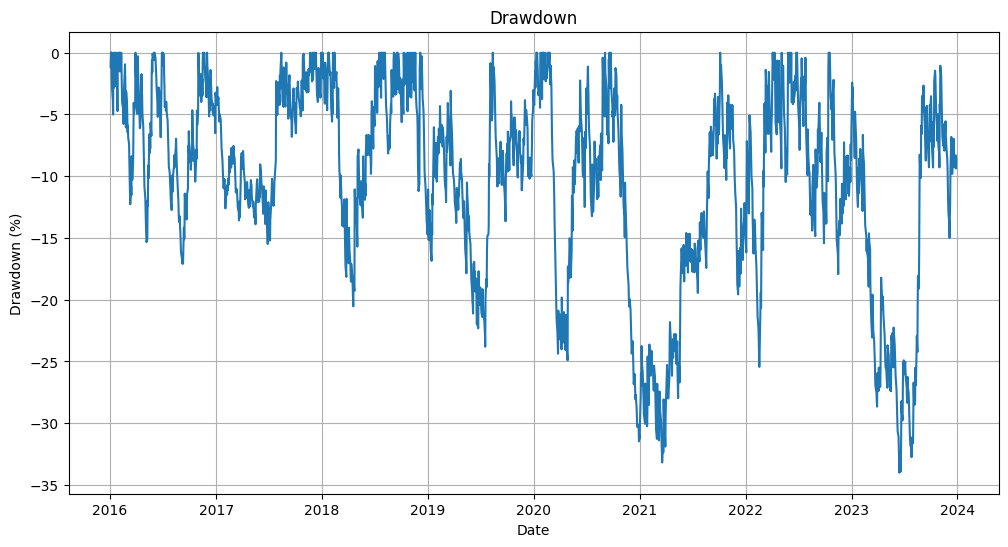

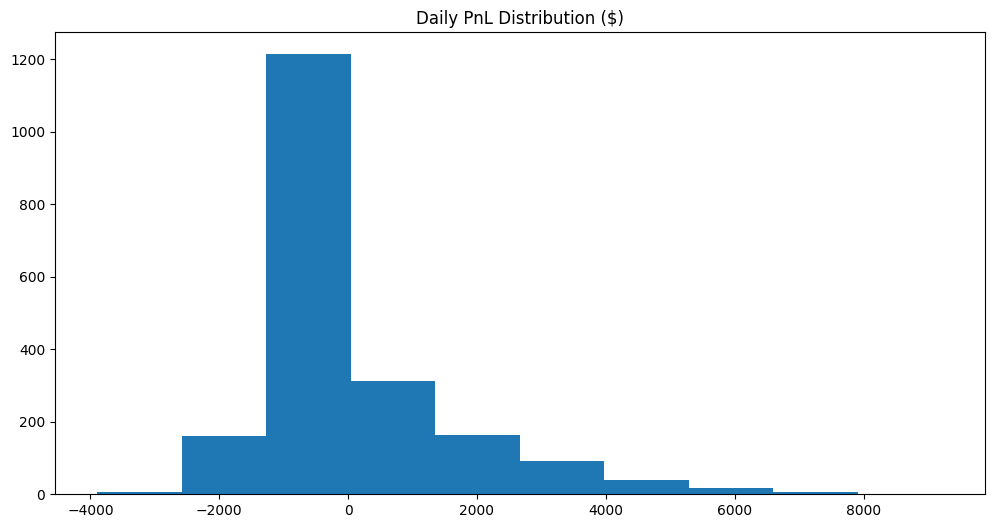

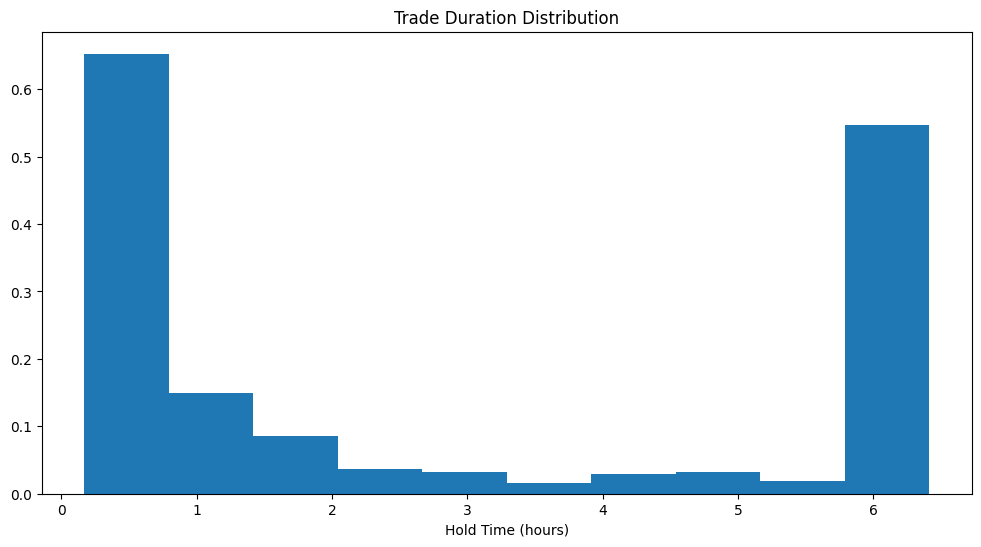

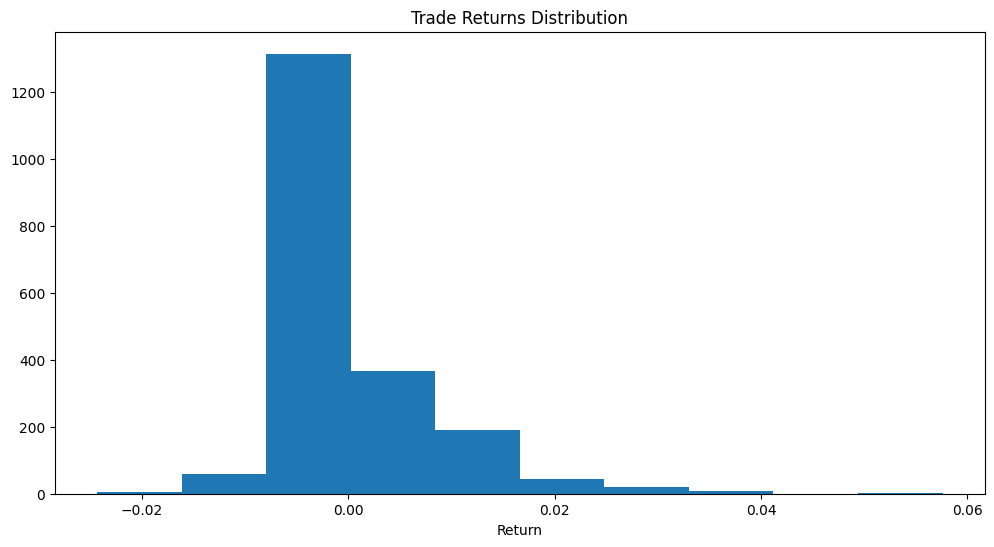

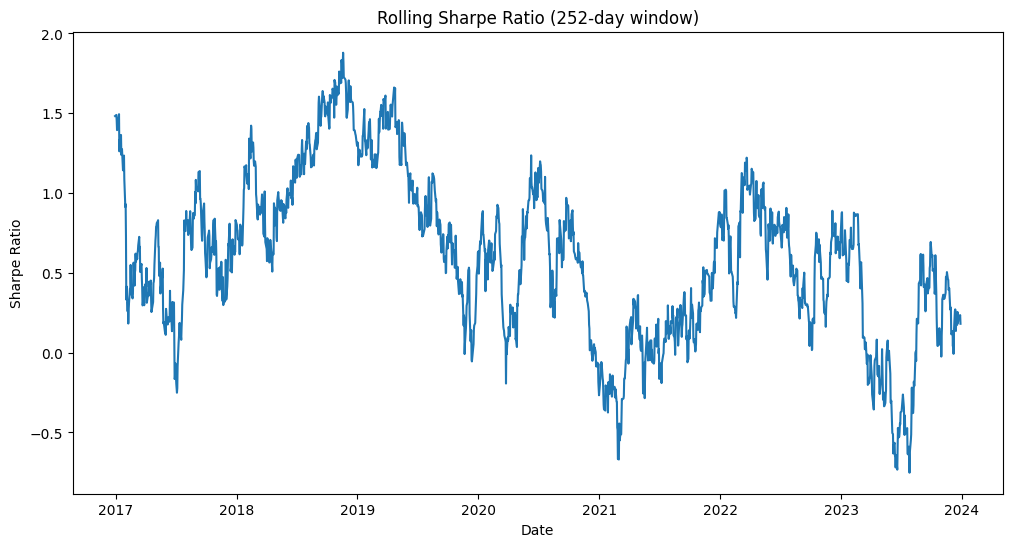

CPU times: user 9.71 s, sys: 477 ms, total: 10.2 s
Wall time: 10 s


In [ ]:
# Backtest strategy

%%time

print(f'Backtesting Results for {interval} ORB strategy on {symbol} between {start_year} and {end_year}:')

positions, final_account_value, equity_curve, dates, buy_hold_equity = backtest_orb_strategy(qqq,
                                                                       signal_price=signal_price,
                                                                    position_bar=position_bar,
                                                                    exec_price=exec_price,
                                                                    commission=commission,
                                                                    slippage=slippage,
                                                                    tp=tp_factor,
                                                                    start_t=start_t,
                                                                    end_t=end_t, second_bar_t=second_bar_t)




bt_metrics_plots(symbol, interval, equity_curve, buy_hold_equity, dates)

# 2. Sensitivity Analysis on QQQ

<ipython-input-18-a7b902291372>:121: RuntimeWarning: invalid value encountered in scalar divide
  position['Return'] = position['Profit/Loss'] / (position['Entry Price'] * position['Shares'])


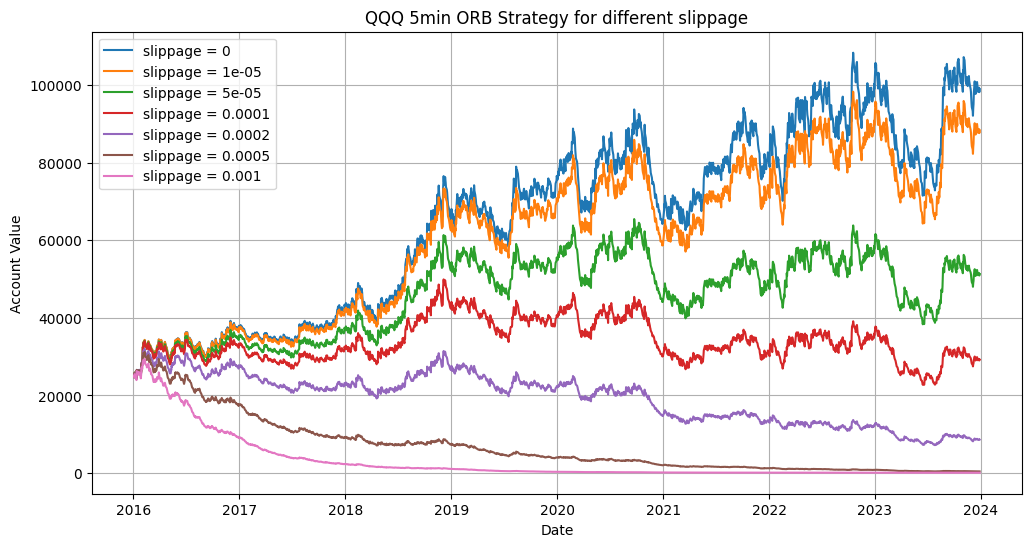

In [ ]:
equity_curves = []

# List of different slippage values
slippages = [0, 0.001/100, 0.005/100, 0.01/100, 0.02/100, 0.05/100, 0.1/100]

# Iterate over each slippage value
for slippage_ in slippages:
    # Perform the backtest and get the equity curve
    _, _, equity_curve, _, _ = backtest_orb_strategy(qqq, signal_price=signal_price,
                                                     position_bar=position_bar,
                                                     exec_price=exec_price,
                                                     commission=commission,
                                                     slippage=slippage_,
                                                     tp=tp_factor,
                                                     start_t=start_t,
                                                     end_t=end_t,
                                                     second_bar_t=second_bar_t)

    # Store the equity curve and the corresponding slippage
    equity_curves.append((equity_curve, slippage_))

# Plot all equity curves on the same chart
plt.figure(figsize=(12, 6))
for equity_curve, slippage_ in equity_curves:
    plt.plot(dates, equity_curve, label=f'slippage = {slippage_}')

# Customize the plot
plt.title(f'{symbol} {interval} ORB Strategy for different slippage')
plt.xlabel('Date')
plt.ylabel('Account Value')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

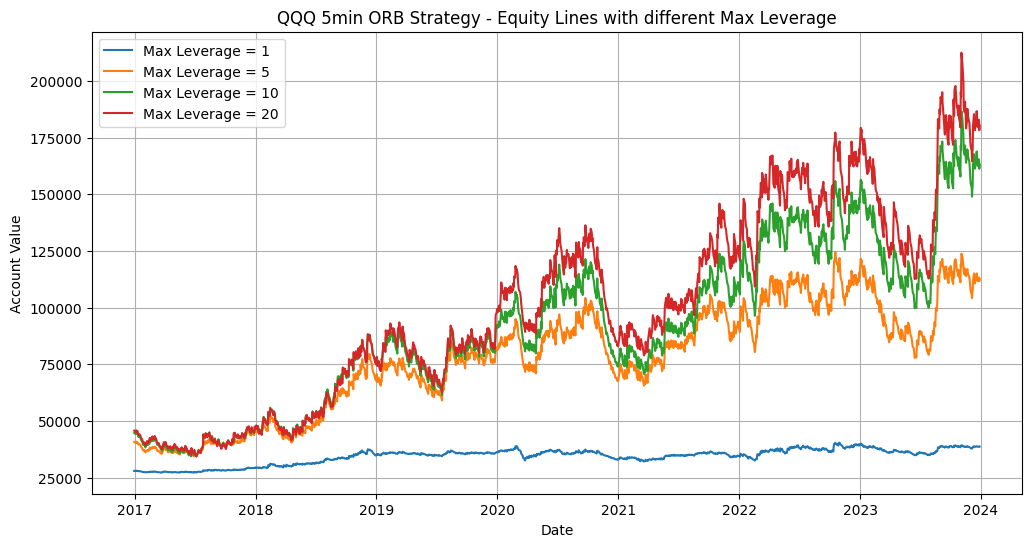

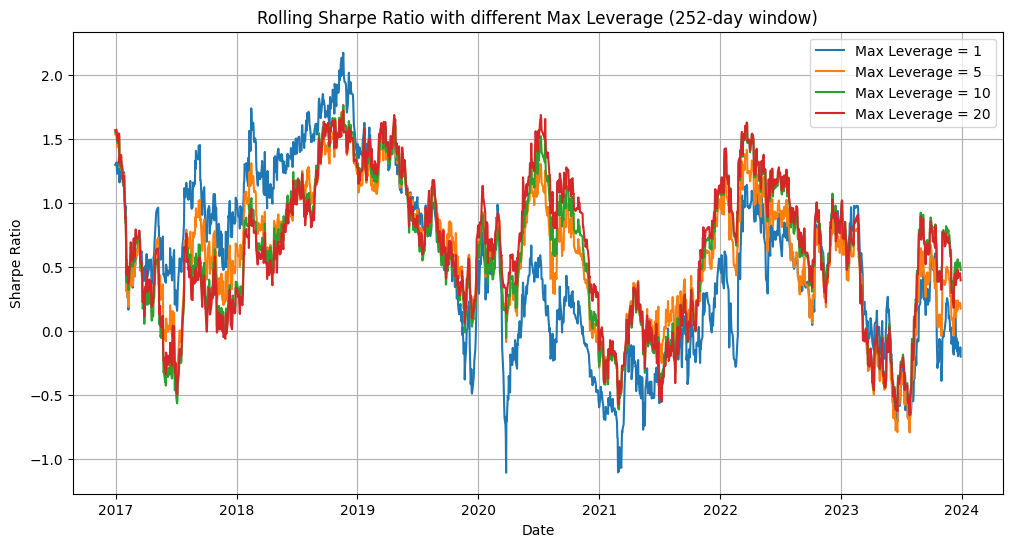

In [ ]:
#Try different leverages - plot Account Values & Sharpe Ratios


sharpes = []
equity_curves = []
max_lvg = [1, 5, 10, 20]

for lev_ in max_lvg:

    window=252

    _, _, equity_curve, _, _ = backtest_orb_strategy(qqq, max_leverage=lev_,
                                                     signal_price=signal_price,
                                                     position_bar=position_bar,
                                                     exec_price=exec_price,
                                                     commission=commission,
                                                     slippage=0,
                                                     tp=tp_factor,
                                                     start_t=start_t,
                                                     end_t=end_t,
                                                     second_bar_t=second_bar_t)

    equity_curves.append((equity_curve, lev_))

    equity_series = pd.Series(equity_curve, index=dates)
    rolling_sharpe = np.sqrt(window) * equity_series.pct_change().rolling(window=window).mean() / equity_series.pct_change().rolling(window=window).std()


    sharpes.append((rolling_sharpe, lev_))


# Plot all equity curves on the same chart
plt.figure(figsize=(12, 6))
for curve, leverage in equity_curves:
    plt.plot(dates[window:], curve[window:], label=f'Max Leverage = {leverage}')

plt.title(f'{symbol} {interval} ORB Strategy - Equity Lines with different Max Leverage')
plt.xlabel('Date')
plt.ylabel('Account Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot Sharpe Ratios
plt.figure(figsize=(12, 6))
for sharpe, leverage in sharpes:
    plt.plot(dates[window:], sharpe[window:], label=f'Max Leverage = {leverage}')

plt.title(f'Rolling Sharpe Ratio with different Max Leverage ({window}-day window)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()


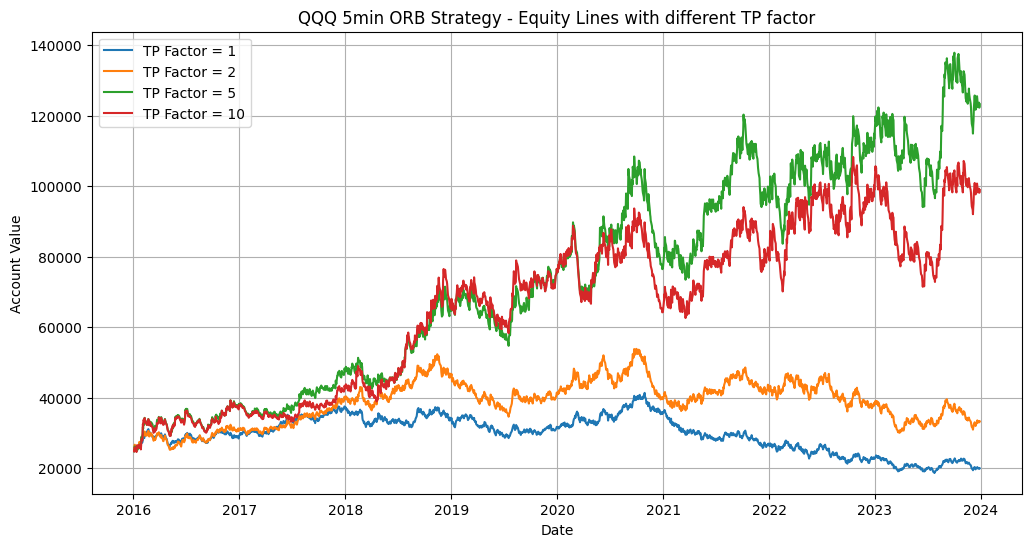

In [ ]:
#Try different TP rules - plot equity curves


equity_curves = []
tp_factors = [1, 2, 5, 10]

for tp in tp_factors:


    _, _, equity_curve, _, _ = backtest_orb_strategy(qqq, max_leverage=4,
                                                     signal_price=signal_price,
                                                     position_bar=position_bar,
                                                     exec_price=exec_price,
                                                     commission=commission,
                                                     slippage=0,
                                                     tp=tp,
                                                     start_t=start_t,
                                                     end_t=end_t,
                                                     second_bar_t=second_bar_t)

    equity_curves.append((equity_curve, tp))

    equity_series = pd.Series(equity_curve, index=dates)


# Plot all equity curves on the same chart
plt.figure(figsize=(12, 6))
for curve, tp in equity_curves:
    plt.plot(dates, curve, label=f'TP Factor = {tp}')

plt.title(f'{symbol} {interval} ORB Strategy - Equity Lines with different TP factor')
plt.xlabel('Date')
plt.ylabel('Account Value')
plt.legend()
plt.grid(True)
plt.show()


# 3. Backtest on different assets

In [ ]:
max_leverage = 4
commission = 0.0005 #dollar per share
slippage = 0.0 #price percentage
tp_factor = 10

_ , _, qqq_equity, qqq_dates, _ = backtest_orb_strategy(qqq, max_leverage=max_leverage,
                                                     signal_price=signal_price,
                                                     position_bar=position_bar,
                                                     exec_price=exec_price,
                                                     commission=commission,
                                                     slippage=slippage,
                                                     tp=tp_factor,
                                                     start_t=start_t,
                                                     end_t=end_t,
                                                     second_bar_t=second_bar_t)

_ , _, tsla_equity, tsla_dates, _ = backtest_orb_strategy(tsla, max_leverage=max_leverage,
                                                     signal_price=signal_price,
                                                     position_bar=position_bar,
                                                     exec_price=exec_price,
                                                     commission=commission,
                                                     slippage=slippage,
                                                     tp=tp_factor,
                                                     start_t=start_t,
                                                     end_t=end_t,
                                                     second_bar_t=second_bar_t)

_ , _, spy_equity, spy_dates, _ = backtest_orb_strategy(spy, max_leverage=max_leverage,
                                                     signal_price=signal_price,
                                                     position_bar=position_bar,
                                                     exec_price=exec_price,
                                                     commission=commission,
                                                     slippage=slippage,
                                                     tp=tp_factor,
                                                     start_t=start_t,
                                                     end_t=end_t,
                                                     second_bar_t=second_bar_t)

qqq_equity = pd.Series(qqq_equity, index=qqq_dates)
tsla_equity = pd.Series(tsla_equity, index=tsla_dates)
spy_equity = pd.Series(spy_equity, index=spy_dates)

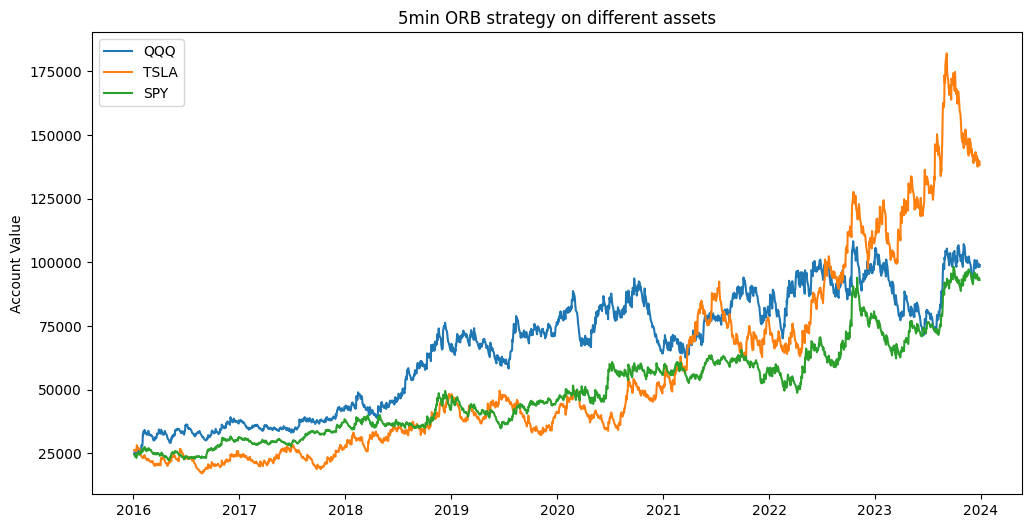

In [ ]:
qqq = pd.DataFrame(qqq_equity, columns=['QQQ'])
tsla = pd.DataFrame(tsla_equity, columns=['TSLA'])
spy = pd.DataFrame(spy_equity, columns=['SPY'])

all_dfs = qqq.merge(tsla, right_index=True, left_index=True, how='inner').merge(spy, right_index=True, left_index=True, how='inner')

all_dfs.iloc[1:].plot(figsize=(12, 6))
plt.ylabel('Account Value')
plt.title('5min ORB strategy on different assets')
plt.show()